# XQuality robust prefix stop-after-layer evaluation

This notebook evaluates the **LLM-assisted prefix stop-after-layer outputs** with metrics that are more robust than relaxed relation F1 alone.

The key idea is:

- relaxed relation coverage tells us how many gold relations can be recovered;
- raw output efficiency tells us how many generated triples were needed to recover them;
- coverage-efficiency F1 balances both, so massive overgeneration is penalized;
- entity-adjusted KG score also includes entity F1.

Run this notebook after copying the patch files into `src/neoolaf/evaluation/...` or after applying the provided patch zip.

## 1. Configuration

Edit only the paths in this cell if your directory names differ.

In [1]:
from pathlib import Path
import sys
import json
import pandas as pd

def find_project_root(start=None) -> Path:
    start = Path(start or Path.cwd()).resolve()
    candidates = [start] + list(start.parents)

    for p in candidates:
        if (p / "src" / "neoolaf").exists():
            return p

    for p in candidates:
        if (p / "pyproject.toml").exists() and (p / "examples" / "XQualityMachine32").exists():
            return p

    raise RuntimeError("Could not find NeoOLAF project root.")

PROJECT_ROOT = find_project_root()
EXAMPLE_ROOT = PROJECT_ROOT / "examples" / "XQualityMachine32"
RUNS_ROOT = EXAMPLE_ROOT / "runs"

SRC_DIR = PROJECT_ROOT / "src"
if SRC_DIR.exists() and str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

PREFIX_RUNS_DIR = RUNS_ROOT / "prefix_stop_after_layer_llm_finalization_exact_eval"
GOLD_PATH = PROJECT_ROOT / "data" / "XQuality" / "Examples" / "XQuality_all_triplets_flat_en.json"
FINAL_EXPORT_DIR = None
OUTPUT_DIR = RUNS_ROOT / "prefix_stop_after_layer_robust_eval"

PROFILE = "xquality_relaxed_recall"
STRICT_COMPLETED_MARKER = False
MIN_TRIPLES = 1

print("CWD:", Path.cwd().resolve())
print("PROJECT_ROOT:", PROJECT_ROOT)
print("PREFIX_RUNS_DIR:", PREFIX_RUNS_DIR)
print("GOLD_PATH:", GOLD_PATH)

if not PREFIX_RUNS_DIR.exists():
    raise FileNotFoundError(f"PREFIX_RUNS_DIR does not exist: {PREFIX_RUNS_DIR}")

if not GOLD_PATH.exists():
    raise FileNotFoundError(f"GOLD_PATH does not exist: {GOLD_PATH}")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CWD: C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32
PROJECT_ROOT: C:\Users\henri\Documents\git\post-doc\NeoOLAF
PREFIX_RUNS_DIR: C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\prefix_stop_after_layer_llm_finalization_exact_eval
GOLD_PATH: C:\Users\henri\Documents\git\post-doc\NeoOLAF\data\XQuality\Examples\XQuality_all_triplets_flat_en.json


## 2. Import the robust ablation evaluator

If this cell fails, copy the files from the patch zip into your repository first:

```text
src/neoolaf/evaluation/metrics/ablation_robust.py
src/neoolaf/evaluation/runners/evaluate_ablation_robust.py
```

In [2]:
from neoolaf.evaluation.runners.evaluate_ablation_robust import (
    evaluate_prefix_stop_after_layer_ablation,
    discover_prefix_folders,
    load_triples_any,
)

print("Robust ablation evaluator imported successfully.")

Robust ablation evaluator imported successfully.


## 3. Discover completed prefix folders

This also automatically skips folders that are empty, explicitly incomplete, or have no usable triples.

In [3]:
prefix_folders = discover_prefix_folders(
    PREFIX_RUNS_DIR,
    min_triples=MIN_TRIPLES,
    strict_completed_marker=STRICT_COMPLETED_MARKER,
)

rows = []
for rec in prefix_folders:
    rows.append({
        "stop_index": rec["stop_index"],
        "layer_name": rec["layer_name"],
        "triple_count": rec["triple_count"],
        "source_path": str(rec["source_path"]),
    })

prefix_df = pd.DataFrame(rows)
display(prefix_df)

if prefix_df.empty:
    raise RuntimeError("No completed prefix folders were discovered. Check PREFIX_RUNS_DIR or completion/triple files.")

,stop_index,layer_name,triple_count,source_path
0,0,prefix_stop_after_00_layer00_preprocessing,124,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...
1,1,prefix_stop_after_01_layer01_linguistic_expres...,841,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...
2,2,prefix_stop_after_02_layer02_candidate_enrichment,1428,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...
3,3,prefix_stop_after_03_layer03_candidate_typing_...,1812,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...
4,4,prefix_stop_after_04_layer04_candidate_relatio...,2669,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...
5,5,prefix_stop_after_05_layer05_candidate_triple_...,2657,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...
6,6,prefix_stop_after_06_layer06_concept_relation_...,2742,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...
7,7,prefix_stop_after_07_layer07_hierarchisation,2642,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...
8,8,prefix_stop_after_08_layer08_axiom_schemata_ex...,2881,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...
9,9,prefix_stop_after_09_layer09_general_axiom_ext...,3121,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...


## 4. Auto-detect the native final export folder

The final export is optional but recommended because it is the reference point for the robust ablation table.

In [4]:
def count_triples_in_folder(folder: Path) -> int:
    triples, _ = load_triples_any(folder)
    return len(triples)


def find_candidate_final_export_dirs(project_root: Path, prefix_runs_dir: Path, output_dir: Path):
    candidates = []
    search_root = project_root / "examples/XQualityMachine32/runs"
    if not search_root.exists():
        return candidates

    prefix_resolved = prefix_runs_dir.resolve()
    output_resolved = output_dir.resolve()

    for kg_file in list(search_root.glob("**/kg_inferred.json")) + list(search_root.glob("**/kg_local.json")) + list(search_root.glob("**/kg.json")):
        folder = kg_file.parent
        try:
            folder_resolved = folder.resolve()
            # Avoid picking our generated prefix folders or evaluation folders.
            if str(folder_resolved).startswith(str(prefix_resolved)):
                continue
            if str(folder_resolved).startswith(str(output_resolved)):
                continue
        except Exception:
            pass

        try:
            triple_count = count_triples_in_folder(folder)
        except Exception:
            triple_count = 0
        if triple_count <= 0:
            continue

        candidates.append({
            "folder": folder,
            "triple_count": triple_count,
            "mtime": kg_file.stat().st_mtime,
            "kg_file": kg_file,
        })

    candidates.sort(key=lambda x: (x["triple_count"] == 226, x["mtime"]), reverse=True)
    return candidates


if FINAL_EXPORT_DIR is None:
    candidates = find_candidate_final_export_dirs(PROJECT_ROOT, PREFIX_RUNS_DIR, OUTPUT_DIR)
    print(f"Found {len(candidates)} candidate final export folders.")
    for c in candidates[:10]:
        print(c["triple_count"], "|", c["folder"])
    FINAL_EXPORT_DIR = candidates[0]["folder"] if candidates else None

print("Selected FINAL_EXPORT_DIR:", FINAL_EXPORT_DIR)
if FINAL_EXPORT_DIR is None:
    print("WARNING: no final export folder selected. The notebook will evaluate prefixes only.")

Found 28 candidate final export folders.
226 | C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\xquality_machine32\sure_resume_from_layer02_parallel_20260702_151953\exports
226 | C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\xquality_machine32\sure_resume_from_layer02_parallel_20260702_151953\exports
226 | C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\xquality_machine32\layer03_from_l2\exports
226 | C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\xquality_machine32\layer03_from_l2\exports
226 | C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\xquality_machine32\layer12_from_l11\exports
226 | C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\xquality_machine32\layer12_from_l11\exports
2657 | C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\prefix_stop_after_layer_exact_cli_eval_nor

## 5. Run robust evaluation

This runs the same XQuality domain evaluator, then adds robust ablation metrics.

The important output file is:

```text
robust_ablation_summary.csv
```

In [5]:
result = evaluate_prefix_stop_after_layer_ablation(
    prefix_runs_dir=PREFIX_RUNS_DIR,
    gold_path=GOLD_PATH,
    output_dir=OUTPUT_DIR,
    profile=PROFILE,
    final_export_dir=FINAL_EXPORT_DIR,
    min_triples=MIN_TRIPLES,
    strict_completed_marker=STRICT_COMPLETED_MARKER,
    make_plots=True,
)

summary_df = result["summary_df"].copy()
per_relation_df = result["per_relation_df"].copy()
errors = result["errors"]

print("Summary CSV:", result["summary_csv"])
print("Per-relation CSV:", result["per_relation_csv"])
print("Errors:", len(errors))
if errors:
    display(pd.DataFrame(errors))

Summary CSV: C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\prefix_stop_after_layer_robust_eval\robust_ablation_summary.csv
Per-relation CSV: C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\prefix_stop_after_layer_robust_eval\robust_ablation_per_relation.csv
Errors: 0


## 6. Main robust ablation table

Recommended reading:

- `gold_relation_coverage`: generous recall / recoverability.
- `raw_output_efficiency`: how many generated triples were useful.
- `coverage_efficiency_f1`: main robust ablation metric.
- `entity_relation_balanced_f1`: stricter KG score including entity quality.
- `overgeneration_factor`: how many raw triples were generated per matched gold relation.

In [6]:
display_cols = [
    "series",
    "layer_name",
    "stop_index",
    "raw_triple_count",
    "relation_tp",
    "gold_relation_count",
    "gold_relation_coverage",
    "raw_output_efficiency",
    "coverage_efficiency_f1",
    "entity_f1",
    "entity_relation_balanced_f1",
    "overgeneration_factor",
    "relation_f1",  # kept only as a diagnostic; do not use alone for noisy prefix outputs
]
existing_cols = [c for c in display_cols if c in summary_df.columns]
main_table = summary_df[existing_cols].sort_values(["series", "stop_index"], na_position="last")
display(main_table)

main_table.to_csv(OUTPUT_DIR / "main_robust_ablation_table.csv", index=False)
print("Saved:", OUTPUT_DIR / "main_robust_ablation_table.csv")

,series,layer_name,stop_index,raw_triple_count,relation_tp,gold_relation_count,gold_relation_coverage,raw_output_efficiency,coverage_efficiency_f1,entity_f1,entity_relation_balanced_f1,overgeneration_factor,relation_f1
13,native_neoolaf_final_export,native_neoolaf_final_export,12,226,193,439,0.439636,0.853982,0.580451,0.554003,0.566919,1.170984,0.610759
0,prefix_stop_after_layer_generated_output,prefix_stop_after_00_layer00_preprocessing,0,124,4,439,0.009112,0.032258,0.014210,0.035533,0.020301,31.000000,0.018059
1,prefix_stop_after_layer_generated_output,prefix_stop_after_01_layer01_linguistic_expres...,1,841,247,439,0.562642,0.293698,0.385937,0.365897,0.375650,3.404858,0.720117
2,prefix_stop_after_layer_generated_output,prefix_stop_after_02_layer02_candidate_enrichment,2,1428,264,439,0.601367,0.184874,0.282807,0.295292,0.288915,5.409091,0.751067
3,prefix_stop_after_layer_generated_output,prefix_stop_after_03_layer03_candidate_typing_...,3,1812,276,439,0.628702,0.152318,0.245224,0.275949,0.259681,6.565217,0.772028
4,prefix_stop_after_layer_generated_output,prefix_stop_after_04_layer04_candidate_relatio...,4,2669,285,439,0.649203,0.106782,0.183398,0.231612,0.204704,9.364912,0.787293
5,prefix_stop_after_layer_generated_output,prefix_stop_after_05_layer05_candidate_triple_...,5,2657,268,439,0.610478,0.100866,0.173127,0.246775,0.203492,9.914179,0.758133
6,prefix_stop_after_layer_generated_output,prefix_stop_after_06_layer06_concept_relation_...,6,2742,288,439,0.656036,0.105033,0.181075,0.237844,0.205613,9.520833,0.792297
7,prefix_stop_after_layer_generated_output,prefix_stop_after_07_layer07_hierarchisation,7,2642,283,439,0.644647,0.107116,0.183707,0.255973,0.213901,9.335689,0.783934
8,prefix_stop_after_layer_generated_output,prefix_stop_after_08_layer08_axiom_schemata_ex...,8,2881,286,439,0.651481,0.099271,0.172289,0.248488,0.203489,10.073427,0.788966


Saved: C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\prefix_stop_after_layer_robust_eval\main_robust_ablation_table.csv


## 7. Compare against native final export

This cell computes deltas against the native final export when it is available.

In [7]:
if "native_neoolaf_final_export" in set(summary_df["series"]):
    final_row = summary_df[summary_df["series"] == "native_neoolaf_final_export"].iloc[0]
    prefix_rows = summary_df[summary_df["series"] == "prefix_stop_after_layer_generated_output"].copy()
    for col in ["gold_relation_coverage", "raw_output_efficiency", "coverage_efficiency_f1", "entity_f1", "entity_relation_balanced_f1", "raw_triple_count"]:
        if col in prefix_rows.columns:
            prefix_rows[f"delta_vs_final_{col}"] = prefix_rows[col] - final_row[col]
    delta_cols = ["layer_name", "stop_index"] + [c for c in prefix_rows.columns if c.startswith("delta_vs_final_")]
    display(prefix_rows[delta_cols].sort_values("stop_index"))
else:
    print("No native final export row found; skipping delta table.")

,layer_name,stop_index,delta_vs_final_gold_relation_coverage,delta_vs_final_raw_output_efficiency,delta_vs_final_coverage_efficiency_f1,delta_vs_final_entity_f1,delta_vs_final_entity_relation_balanced_f1,delta_vs_final_raw_triple_count
0,prefix_stop_after_00_layer00_preprocessing,0,-0.430524,-0.821724,-0.566242,-0.518470,-0.546618,-102
1,prefix_stop_after_01_layer01_linguistic_expres...,1,0.123007,-0.560284,-0.194514,-0.188106,-0.191268,615
2,prefix_stop_after_02_layer02_candidate_enrichment,2,0.161731,-0.669108,-0.297644,-0.258710,-0.278004,1202
3,prefix_stop_after_03_layer03_candidate_typing_...,3,0.189066,-0.701664,-0.335227,-0.278053,-0.307237,1586
4,prefix_stop_after_04_layer04_candidate_relatio...,4,0.209567,-0.747201,-0.397053,-0.322391,-0.362214,2443
5,prefix_stop_after_05_layer05_candidate_triple_...,5,0.170843,-0.753117,-0.407325,-0.307227,-0.363426,2431
6,prefix_stop_after_06_layer06_concept_relation_...,6,0.216401,-0.748949,-0.399376,-0.316159,-0.361306,2516
7,prefix_stop_after_07_layer07_hierarchisation,7,0.205011,-0.746866,-0.396745,-0.298030,-0.353018,2416
8,prefix_stop_after_08_layer08_axiom_schemata_ex...,8,0.211845,-0.754711,-0.408162,-0.305514,-0.363429,2655
9,prefix_stop_after_09_layer09_general_axiom_ext...,9,0.227790,-0.760102,-0.415844,-0.318647,-0.373195,2895


## 8. Plots

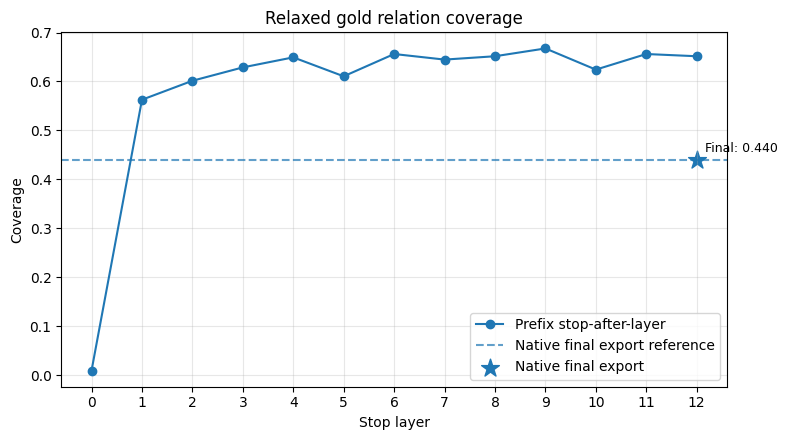

Saved: C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\prefix_stop_after_layer_robust_eval\notebook_gold_relation_coverage.png


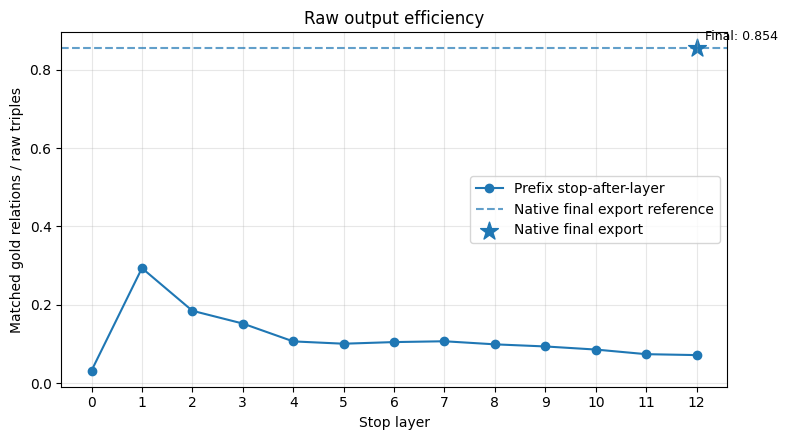

Saved: C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\prefix_stop_after_layer_robust_eval\notebook_raw_output_efficiency.png


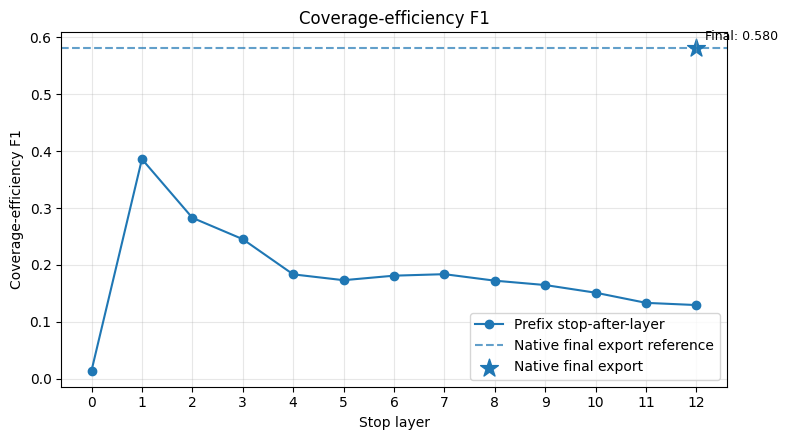

Saved: C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\prefix_stop_after_layer_robust_eval\notebook_coverage_efficiency_f1.png


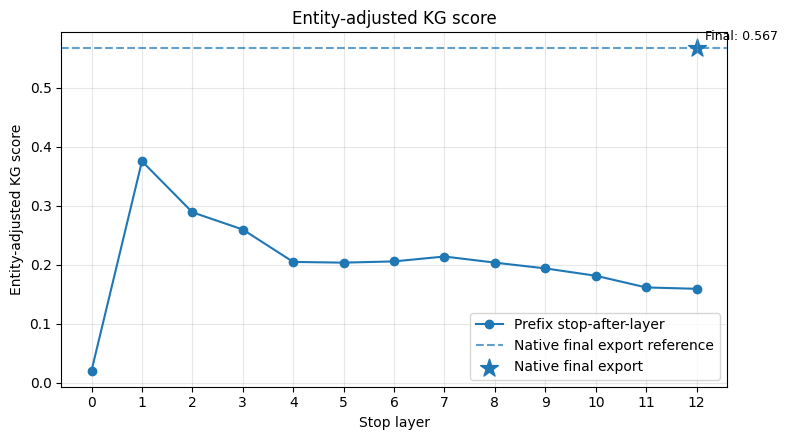

Saved: C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\prefix_stop_after_layer_robust_eval\notebook_entity_relation_balanced_f1.png


In [8]:
import matplotlib.pyplot as plt
import pandas as pd

plot_df = summary_df[summary_df["series"] == "prefix_stop_after_layer_generated_output"].copy()
plot_df = plot_df[plot_df["stop_index"].notna()].sort_values("stop_index")

final_row = None
if "native_neoolaf_final_export" in set(summary_df["series"]):
    final_row = summary_df[summary_df["series"] == "native_neoolaf_final_export"].iloc[0]


def plot_metric(metric, title, ylabel):
    fig, ax = plt.subplots(figsize=(8, 4.5))

    # Prefix stop-after-layer curve
    ax.plot(
        plot_df["stop_index"],
        plot_df[metric],
        marker="o",
        label="Prefix stop-after-layer"
    )

    # Native final export as both reference line and actual point
    if final_row is not None and metric in final_row.index and pd.notna(final_row[metric]):
        final_x = final_row["stop_index"] if pd.notna(final_row.get("stop_index", None)) else 12
        final_y = final_row[metric]

        # Horizontal reference line
        ax.axhline(
            final_y,
            linestyle="--",
            alpha=0.7,
            label="Native final export reference"
        )

        # Actual final export point at layer 12
        ax.scatter(
            [final_x],
            [final_y],
            marker="*",
            s=180,
            label="Native final export"
        )

        # Small text label
        ax.annotate(
            f"Final: {final_y:.3f}",
            xy=(final_x, final_y),
            xytext=(6, 6),
            textcoords="offset points",
            fontsize=9
        )

    ax.set_title(title)
    ax.set_xlabel("Stop layer")
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)

    # Make sure Layer 12 appears on the x-axis even if prefixes only go to 5/6
    xticks = sorted(set(plot_df["stop_index"].astype(int).tolist() + [12]))
    ax.set_xticks(xticks)

    ax.legend()
    fig.tight_layout()

    out_path = OUTPUT_DIR / f"notebook_{metric}.png"
    fig.savefig(out_path, dpi=160)
    plt.show()
    print("Saved:", out_path)


plot_metric("gold_relation_coverage", "Relaxed gold relation coverage", "Coverage")
plot_metric("raw_output_efficiency", "Raw output efficiency", "Matched gold relations / raw triples")
plot_metric("coverage_efficiency_f1", "Coverage-efficiency F1", "Coverage-efficiency F1")
plot_metric("entity_relation_balanced_f1", "Entity-adjusted KG score", "Entity-adjusted KG score")

## 9. Per-relation robust diagnostics

In [9]:
if not per_relation_df.empty:
    per_cols = [
        "series", "layer_name", "stop_index", "relation", "pred_count", "gt_count", "tp", "fp", "fn",
        "relation_coverage", "canonical_output_efficiency", "coverage_canonical_efficiency_f1",
    ]
    per_cols = [c for c in per_cols if c in per_relation_df.columns]
    display(per_relation_df[per_cols].sort_values(["relation", "series", "stop_index"], na_position="last"))
else:
    print("No per-relation rows produced.")

,series,layer_name,stop_index,relation,pred_count,gt_count,tp,fp,fn,relation_coverage,canonical_output_efficiency,coverage_canonical_efficiency_f1
65,native_neoolaf_final_export,native_neoolaf_final_export,12,CAUSES,24,105,24,0,81,0.228571,1.0,0.372093
0,prefix_stop_after_layer_generated_output,prefix_stop_after_00_layer00_preprocessing,0,CAUSES,0,105,0,0,105,0.000000,0.0,0.000000
5,prefix_stop_after_layer_generated_output,prefix_stop_after_01_layer01_linguistic_expres...,1,CAUSES,37,105,37,0,68,0.352381,1.0,0.521127
10,prefix_stop_after_layer_generated_output,prefix_stop_after_02_layer02_candidate_enrichment,2,CAUSES,38,105,38,0,67,0.361905,1.0,0.531469
15,prefix_stop_after_layer_generated_output,prefix_stop_after_03_layer03_candidate_typing_...,3,CAUSES,42,105,42,0,63,0.400000,1.0,0.571429
...,...,...,...,...,...,...,...,...,...,...,...,...
44,prefix_stop_after_layer_generated_output,prefix_stop_after_08_layer08_axiom_schemata_ex...,8,TRIGGERS,64,83,64,0,19,0.771084,1.0,0.870748
49,prefix_stop_after_layer_generated_output,prefix_stop_after_09_layer09_general_axiom_ext...,9,TRIGGERS,62,83,62,0,21,0.746988,1.0,0.855172
54,prefix_stop_after_layer_generated_output,prefix_stop_after_10_layer10_validation_reasoning,10,TRIGGERS,61,83,61,0,22,0.734940,1.0,0.847222
59,prefix_stop_after_layer_generated_output,prefix_stop_after_11_layer11_inference_completion,11,TRIGGERS,61,83,61,0,22,0.734940,1.0,0.847222


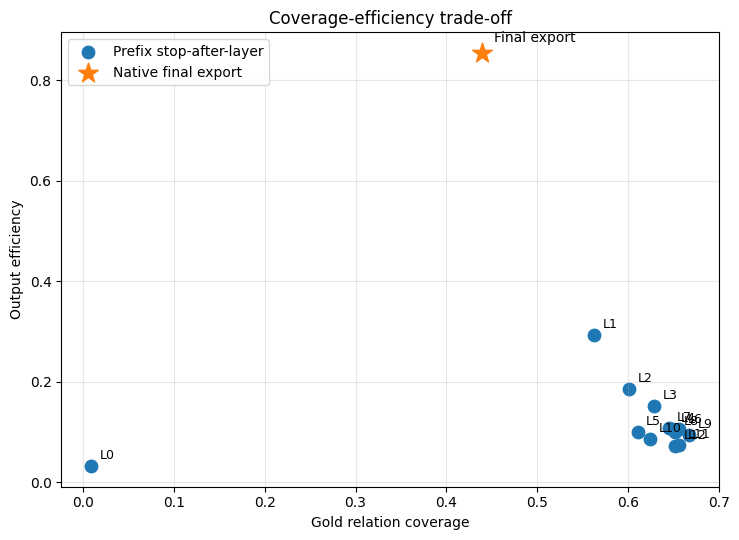

Saved: C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\prefix_stop_after_layer_robust_eval\notebook_coverage_efficiency_tradeoff.png


In [10]:
import matplotlib.pyplot as plt
import pandas as pd

plot_df = summary_df[
    summary_df["series"] == "prefix_stop_after_layer_generated_output"
].copy()

plot_df = plot_df[plot_df["stop_index"].notna()].sort_values("stop_index")

final_row = None
if "native_neoolaf_final_export" in set(summary_df["series"]):
    final_row = summary_df[
        summary_df["series"] == "native_neoolaf_final_export"
    ].iloc[0]

fig, ax = plt.subplots(figsize=(7.5, 5.5))

ax.scatter(
    plot_df["gold_relation_coverage"],
    plot_df["raw_output_efficiency"],
    s=80,
    label="Prefix stop-after-layer"
)

for _, row in plot_df.iterrows():
    ax.annotate(
        f"L{int(row['stop_index'])}",
        xy=(row["gold_relation_coverage"], row["raw_output_efficiency"]),
        xytext=(6, 5),
        textcoords="offset points",
        fontsize=9
    )

if final_row is not None:
    ax.scatter(
        [final_row["gold_relation_coverage"]],
        [final_row["raw_output_efficiency"]],
        marker="*",
        s=220,
        label="Native final export"
    )

    ax.annotate(
        "Final export",
        xy=(final_row["gold_relation_coverage"], final_row["raw_output_efficiency"]),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=10
    )

ax.set_title("Coverage-efficiency trade-off")
ax.set_xlabel("Gold relation coverage")
ax.set_ylabel("Output efficiency")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()

out_path = OUTPUT_DIR / "notebook_coverage_efficiency_tradeoff.png"
fig.savefig(out_path, dpi=180)
plt.show()

print("Saved:", out_path)

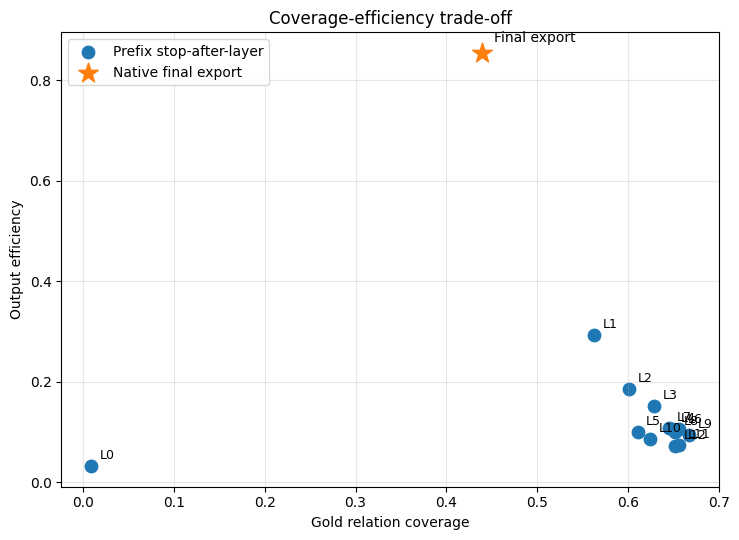

Saved: C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\prefix_stop_after_layer_robust_eval\notebook_coverage_efficiency_tradeoff.png


In [11]:
import matplotlib.pyplot as plt
import pandas as pd

plot_df = summary_df[
    summary_df["series"] == "prefix_stop_after_layer_generated_output"
].copy()

plot_df = plot_df[plot_df["stop_index"].notna()].sort_values("stop_index")

final_row = None
if "native_neoolaf_final_export" in set(summary_df["series"]):
    final_row = summary_df[
        summary_df["series"] == "native_neoolaf_final_export"
    ].iloc[0]

fig, ax = plt.subplots(figsize=(7.5, 5.5))

ax.scatter(
    plot_df["gold_relation_coverage"],
    plot_df["raw_output_efficiency"],
    s=80,
    label="Prefix stop-after-layer"
)

for _, row in plot_df.iterrows():
    ax.annotate(
        f"L{int(row['stop_index'])}",
        xy=(row["gold_relation_coverage"], row["raw_output_efficiency"]),
        xytext=(6, 5),
        textcoords="offset points",
        fontsize=9
    )

if final_row is not None:
    ax.scatter(
        [final_row["gold_relation_coverage"]],
        [final_row["raw_output_efficiency"]],
        marker="*",
        s=220,
        label="Native final export"
    )

    ax.annotate(
        "Final export",
        xy=(final_row["gold_relation_coverage"], final_row["raw_output_efficiency"]),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=10
    )

ax.set_title("Coverage-efficiency trade-off")
ax.set_xlabel("Gold relation coverage")
ax.set_ylabel("Output efficiency")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()

out_path = OUTPUT_DIR / "notebook_coverage_efficiency_tradeoff.png"
fig.savefig(out_path, dpi=180)
plt.show()

print("Saved:", out_path)

## 10. Paper-safe interpretation

Use the metrics this way:

1. **Relaxed gold relation coverage** is a diagnostic of information availability, not the main ablation score.
2. **Coverage-efficiency F1** is the main score for prefix-finalized outputs because it penalizes overgeneration.
3. **Entity-adjusted KG score** is stricter and better reflects whether the output is useful as a KG, not just as a source of recoverable relation hints.
4. If an early prefix has higher relaxed coverage but much lower efficiency/entity quality, the right conclusion is not that the early layer is better. The right conclusion is that early textual/candidate layers contain recoverable evidence, while later native NeoOLAF layers improve compactness, normalization, validation, and export quality.

In [13]:
import numpy as np
import pandas as pd

def fbeta(precision_like, recall_like, beta=1.0):
    p = float(precision_like) if pd.notna(precision_like) else 0.0
    r = float(recall_like) if pd.notna(recall_like) else 0.0
    if p <= 0 or r <= 0:
        return 0.0
    b2 = beta ** 2
    return (1 + b2) * p * r / ((b2 * p) + r)

def harmonic2(a, b):
    a = float(a) if pd.notna(a) else 0.0
    b = float(b) if pd.notna(b) else 0.0
    if a <= 0 or b <= 0:
        return 0.0
    return 2 * a * b / (a + b)

summary_df = summary_df.copy()

summary_df["coverage_efficiency_f05"] = summary_df.apply(
    lambda r: fbeta(
        r["raw_output_efficiency"],
        r["gold_relation_coverage"],
        beta=0.5,
    ),
    axis=1,
)

summary_df["entity_adjusted_ce_f05"] = summary_df.apply(
    lambda r: harmonic2(
        r["coverage_efficiency_f05"],
        r["entity_f1"],
    ),
    axis=1,
)

summary_df[[
    "series",
    "layer_name",
    "stop_index",
    "raw_triple_count",
    "gold_relation_coverage",
    "raw_output_efficiency",
    "coverage_efficiency_f1",
    "coverage_efficiency_f05",
    "entity_f1",
    "entity_adjusted_ce_f05",
    "relation_f1",
]].sort_values(["series", "stop_index"])

,series,layer_name,stop_index,raw_triple_count,gold_relation_coverage,raw_output_efficiency,coverage_efficiency_f1,coverage_efficiency_f05,entity_f1,entity_adjusted_ce_f05,relation_f1
13,native_neoolaf_final_export,native_neoolaf_final_export,12,226,0.439636,0.853982,0.580451,0.718541,0.554003,0.625634,0.610759
0,prefix_stop_after_layer_generated_output,prefix_stop_after_00_layer00_preprocessing,0,124,0.009112,0.032258,0.014210,0.021390,0.035533,0.026705,0.018059
1,prefix_stop_after_layer_generated_output,prefix_stop_after_01_layer01_linguistic_expres...,1,841,0.562642,0.293698,0.385937,0.324744,0.365897,0.344094,0.720117
2,prefix_stop_after_layer_generated_output,prefix_stop_after_02_layer02_candidate_enrichment,2,1428,0.601367,0.184874,0.282807,0.214599,0.295292,0.248561,0.751067
3,prefix_stop_after_layer_generated_output,prefix_stop_after_03_layer03_candidate_typing_...,3,1812,0.628702,0.152318,0.245224,0.179524,0.275949,0.217530,0.772028
4,prefix_stop_after_layer_generated_output,prefix_stop_after_04_layer04_candidate_relatio...,4,2669,0.649203,0.106782,0.183398,0.128205,0.231612,0.165050,0.787293
5,prefix_stop_after_layer_generated_output,prefix_stop_after_05_layer05_candidate_triple_...,5,2657,0.610478,0.100866,0.173127,0.121081,0.246775,0.162453,0.758133
6,prefix_stop_after_layer_generated_output,prefix_stop_after_06_layer06_concept_relation_...,6,2742,0.656036,0.105033,0.181075,0.126238,0.237844,0.164935,0.792297
7,prefix_stop_after_layer_generated_output,prefix_stop_after_07_layer07_hierarchisation,7,2642,0.644647,0.107116,0.183707,0.128555,0.255973,0.171153,0.783934
8,prefix_stop_after_layer_generated_output,prefix_stop_after_08_layer08_axiom_schemata_ex...,8,2881,0.651481,0.099271,0.172289,0.119535,0.248488,0.161420,0.788966


In [14]:
prefix_df = summary_df[
    summary_df["series"] == "prefix_stop_after_layer_generated_output"
].copy()

final_df = summary_df[
    summary_df["series"] == "native_neoolaf_final_export"
].copy()

if len(final_df) == 0:
    raise ValueError("No native_neoolaf_final_export row found.")

final = final_df.iloc[0]

if 12 in set(prefix_df["stop_index"]):
    ref = prefix_df[prefix_df["stop_index"] == 12].iloc[0]
    ref_name = "LLM-finalized Layer 12 prefix"
else:
    ref = prefix_df.sort_values("coverage_efficiency_f05", ascending=False).iloc[0]
    ref_name = "Best prefix by CE-F0.5"

def safe_ratio(a, b):
    if pd.isna(a) or pd.isna(b) or float(b) == 0:
        return np.nan
    return float(a) / float(b)

finalization_gain = pd.DataFrame([
    {
        "comparison": f"Native final export vs {ref_name}",
        "reference_layer": ref["layer_name"],
        "raw_triple_count_reference": ref["raw_triple_count"],
        "raw_triple_count_final": final["raw_triple_count"],
        "compression_factor_reference_over_final": safe_ratio(
            ref["raw_triple_count"],
            final["raw_triple_count"],
        ),
        "relation_tp_reference": ref["relation_tp"],
        "relation_tp_final": final["relation_tp"],
        "coverage_reference": ref["gold_relation_coverage"],
        "coverage_final": final["gold_relation_coverage"],
        "coverage_delta_final_minus_reference": final["gold_relation_coverage"] - ref["gold_relation_coverage"],
        "efficiency_reference": ref["raw_output_efficiency"],
        "efficiency_final": final["raw_output_efficiency"],
        "efficiency_gain_factor": safe_ratio(
            final["raw_output_efficiency"],
            ref["raw_output_efficiency"],
        ),
        "entity_f1_reference": ref["entity_f1"],
        "entity_f1_final": final["entity_f1"],
        "entity_f1_delta": final["entity_f1"] - ref["entity_f1"],
        "ce_f05_reference": ref["coverage_efficiency_f05"],
        "ce_f05_final": final["coverage_efficiency_f05"],
        "ce_f05_delta": final["coverage_efficiency_f05"] - ref["coverage_efficiency_f05"],
        "entity_adjusted_ce_f05_reference": ref["entity_adjusted_ce_f05"],
        "entity_adjusted_ce_f05_final": final["entity_adjusted_ce_f05"],
        "entity_adjusted_ce_f05_delta": final["entity_adjusted_ce_f05"] - ref["entity_adjusted_ce_f05"],
    }
])

display(finalization_gain.T)

out_path = OUTPUT_DIR / "finalization_gain_table.csv"
finalization_gain.to_csv(out_path, index=False)
print("Saved:", out_path)

,0
comparison,Native final export vs LLM-finalized Layer 12 ...
reference_layer,prefix_stop_after_12_layer12_serialization
raw_triple_count_reference,3981
raw_triple_count_final,226
compression_factor_reference_over_final,17.615044
relation_tp_reference,286
relation_tp_final,193
coverage_reference,0.651481
coverage_final,0.439636
coverage_delta_final_minus_reference,-0.211845


Saved: C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\prefix_stop_after_layer_robust_eval\finalization_gain_table.csv


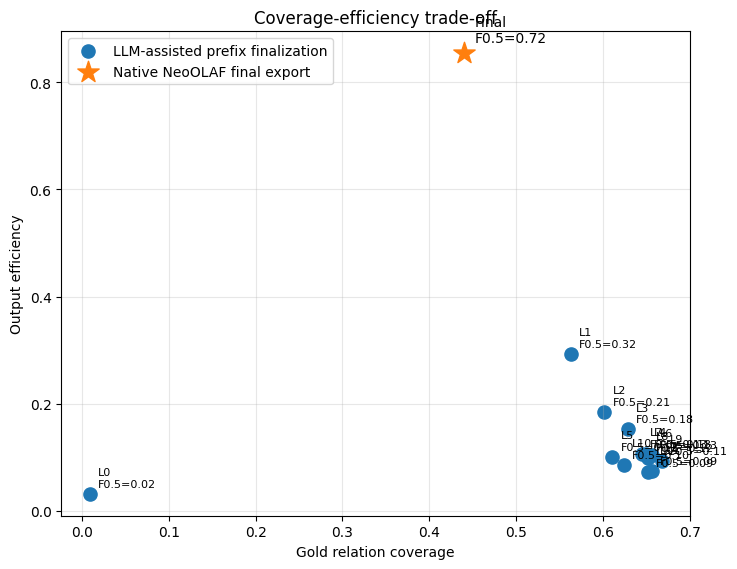

Saved: C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\prefix_stop_after_layer_robust_eval\pareto_coverage_efficiency_f05.png


In [15]:
import matplotlib.pyplot as plt

prefix_plot_df = summary_df[
    summary_df["series"] == "prefix_stop_after_layer_generated_output"
].copy()
prefix_plot_df = prefix_plot_df[prefix_plot_df["stop_index"].notna()].sort_values("stop_index")

final = summary_df[
    summary_df["series"] == "native_neoolaf_final_export"
].iloc[0]

fig, ax = plt.subplots(figsize=(7.5, 5.8))

ax.scatter(
    prefix_plot_df["gold_relation_coverage"],
    prefix_plot_df["raw_output_efficiency"],
    s=90,
    label="LLM-assisted prefix finalization"
)

for _, row in prefix_plot_df.iterrows():
    ax.annotate(
        f"L{int(row['stop_index'])}\nF0.5={row['coverage_efficiency_f05']:.2f}",
        xy=(row["gold_relation_coverage"], row["raw_output_efficiency"]),
        xytext=(6, 5),
        textcoords="offset points",
        fontsize=8
    )

ax.scatter(
    [final["gold_relation_coverage"]],
    [final["raw_output_efficiency"]],
    marker="*",
    s=260,
    label="Native NeoOLAF final export"
)

ax.annotate(
    f"Final\nF0.5={final['coverage_efficiency_f05']:.2f}",
    xy=(final["gold_relation_coverage"], final["raw_output_efficiency"]),
    xytext=(8, 8),
    textcoords="offset points",
    fontsize=10
)

ax.set_title("Coverage-efficiency trade-off")
ax.set_xlabel("Gold relation coverage")
ax.set_ylabel("Output efficiency")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()

out_path = OUTPUT_DIR / "pareto_coverage_efficiency_f05.png"
fig.savefig(out_path, dpi=180)
plt.show()

print("Saved:", out_path)

In [16]:
prefix_delta_df = prefix_plot_df.copy()

prefix_delta_df["delta_relation_tp"] = prefix_delta_df["relation_tp"].diff()
prefix_delta_df["delta_gold_coverage"] = prefix_delta_df["gold_relation_coverage"].diff()
prefix_delta_df["delta_raw_triples"] = prefix_delta_df["raw_triple_count"].diff()
prefix_delta_df["delta_ce_f05"] = prefix_delta_df["coverage_efficiency_f05"].diff()
prefix_delta_df["delta_entity_adjusted_ce_f05"] = prefix_delta_df["entity_adjusted_ce_f05"].diff()

prefix_delta_df["marginal_tp_per_added_triple"] = prefix_delta_df.apply(
    lambda r: (
        r["delta_relation_tp"] / r["delta_raw_triples"]
        if pd.notna(r["delta_raw_triples"]) and r["delta_raw_triples"] > 0
        else np.nan
    ),
    axis=1,
)

display(prefix_delta_df[[
    "stop_index",
    "layer_name",
    "relation_tp",
    "delta_relation_tp",
    "raw_triple_count",
    "delta_raw_triples",
    "marginal_tp_per_added_triple",
    "gold_relation_coverage",
    "delta_gold_coverage",
    "coverage_efficiency_f05",
    "delta_ce_f05",
    "entity_adjusted_ce_f05",
    "delta_entity_adjusted_ce_f05",
]])

,stop_index,layer_name,relation_tp,delta_relation_tp,raw_triple_count,delta_raw_triples,marginal_tp_per_added_triple,gold_relation_coverage,delta_gold_coverage,coverage_efficiency_f05,delta_ce_f05,entity_adjusted_ce_f05,delta_entity_adjusted_ce_f05
0,0,prefix_stop_after_00_layer00_preprocessing,4,NaN,124,NaN,NaN,0.009112,NaN,0.021390,NaN,0.026705,NaN
1,1,prefix_stop_after_01_layer01_linguistic_expres...,247,243.0,841,717.0,0.338912,0.562642,0.553531,0.324744,0.303353,0.344094,0.317389
2,2,prefix_stop_after_02_layer02_candidate_enrichment,264,17.0,1428,587.0,0.028961,0.601367,0.038724,0.214599,-0.110144,0.248561,-0.095533
3,3,prefix_stop_after_03_layer03_candidate_typing_...,276,12.0,1812,384.0,0.031250,0.628702,0.027335,0.179524,-0.035075,0.217530,-0.031031
4,4,prefix_stop_after_04_layer04_candidate_relatio...,285,9.0,2669,857.0,0.010502,0.649203,0.020501,0.128205,-0.051319,0.165050,-0.052480
5,5,prefix_stop_after_05_layer05_candidate_triple_...,268,-17.0,2657,-12.0,NaN,0.610478,-0.038724,0.121081,-0.007124,0.162453,-0.002596
6,6,prefix_stop_after_06_layer06_concept_relation_...,288,20.0,2742,85.0,0.235294,0.656036,0.045558,0.126238,0.005158,0.164935,0.002482
7,7,prefix_stop_after_07_layer07_hierarchisation,283,-5.0,2642,-100.0,NaN,0.644647,-0.011390,0.128555,0.002316,0.171153,0.006218
8,8,prefix_stop_after_08_layer08_axiom_schemata_ex...,286,3.0,2881,239.0,0.012552,0.651481,0.006834,0.119535,-0.009019,0.161420,-0.009733
9,9,prefix_stop_after_09_layer09_general_axiom_ext...,293,7.0,3121,240.0,0.029167,0.667426,0.015945,0.113364,-0.006171,0.153021,-0.008398
